# ```Seminar 6: SIREN```

Seminar based on paper: [Implicit Neural Representations with Periodic Activation Functions](https://www.vincentsitzmann.com/siren/).

Code based on [Colab Notebook](https://colab.research.google.com/github/vsitzmann/siren/blob/master/explore_siren.ipynb) from original paper authors.

## Get started

In [20]:
%%bash
pip install open3d

In [21]:
from google.colab import output
output.enable_custom_widget_manager()

In [22]:
import os
import io
import skimage
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from IPython.display import Audio
import scipy.io.wavfile as wavfile

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import Resize, Compose, ToTensor, Normalize

In [23]:
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
DEVICE

device(type='cuda')

# Introduction

Instead of storing data as discrete grids or meshes, an *implicit neural representation* uses a small neural network as a **continuous function**: you feed it a coordinate $(x,y)$ for an image, $t$ for audio, or $(x,y,z)$ for a 3D shape, and it returns the value (color, amplitude, or signed distance).

A **SIREN** (Sinusoidal Representation Network) swaps out the usual ReLU activations for sine waves, letting it naturally capture high-frequency details—fine textures in images, crisp audio transients, or tiny surface features—without positional encoding.

In this notebook we’ll:

1. Train a **ReLU-MLP** baseline.
2. Swap in **SIREN** layers.
3. Compare both on mapping:

   * **Images**: $(x,y)$ $\to$ RGB
   * **Audio**: $t$ $\to$ amplitude
   * **SDFs**: $(x,y,z)$ $\to$ distance to surface

By learning truly continuous representations instead of default discrete samples, these networks can model signals with sub-pixel and sub-voxel precision.


## Models

### ReLU based MLP

This the most basic MLP with ReLU activations:

$$
\Psi(\mathbf{x}) \;=\; W_{n}\;\bigl(\rho_{n-1}\circ\rho_{n-2}\circ\cdots\circ\rho_{0}\bigr)(\mathbf{x}) \;+\;\mathbf{b}_{n},
\qquad
\rho_{i}(\mathbf{z}) \;=\;\max\bigl(0,\;W_{i}\,\mathbf{z} \;+\;\mathbf{b}_{i}\bigr)\,.
$$

Each layer is $\text{ReLU}(W_i x + \mathbf{b}_i)$ except the last one, which is just $W_n x + \mathbf{b}_n$


In [24]:
class Based_MLP(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers, out_features):
        super().__init__()

        self.net = []
        self.net.append(nn.Linear(in_features, hidden_features))
        self.net.append(nn.ReLU())

        for i in range(hidden_layers):
            self.net.append(nn.Linear(hidden_features, hidden_features))
            self.net.append(nn.ReLU())

        self.net.append(nn.Linear(hidden_features, out_features))

        self.net = nn.Sequential(*self.net)

    def forward(self, coords):
        if self.training:
            coords = coords.clone().detach().requires_grad_(True) # allows to take derivative w.r.t. input
        else:
            coords = coords
        output = self.net(coords)
        return output, coords

### SIREN model

It's not that far from previous model in terms of architecture, we just replace ReLUs with $\sin$ function:

$$
\Phi(\mathbf{x}) \;=\; W_{n}\;\bigl(\phi_{n-1}\circ\phi_{n-2}\circ\cdots\circ\phi_{0}\bigr)(\mathbf{x}) \;+\;\mathbf{b}_{n},
\qquad
\phi_{i}(\mathbf{z}) \;=\;\sin\bigl(W_{i}\,\mathbf{z} \;+\;\mathbf{b}_{i}\bigr)\,.
$$


Here each layer is $\sin(W_{i}\,\mathbf{x} + \mathbf{b}_{i})$ again except the last one, which is just $W_n x + \mathbf{b}_n$

Code below is taken straight from original paper's [notebook](https://colab.research.google.com/github/vsitzmann/siren/blob/master/explore_siren.ipynb):

In [25]:
class SineLayer(nn.Module):
    # See paper sec. 3.2, final paragraph, and supplement Sec. 1.5 for discussion of omega_0.

    # If is_first=True, omega_0 is a frequency factor which simply multiplies the activations before the
    # nonlinearity. Different signals may require different omega_0 in the first layer - this is a
    # hyperparameter.

    # If is_first=False, then the weights will be divided by omega_0 so as to keep the magnitude of
    # activations constant, but boost gradients to the weight matrix (see supplement Sec. 1.5)

    def __init__(self, in_features, out_features, bias=True,
                 is_first=False, omega_0=30):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first

        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)

        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features,
                                             1 / self.in_features)
            else:
                self.linear.weight.uniform_(-np.sqrt(6 / self.in_features) / self.omega_0,
                                             np.sqrt(6 / self.in_features) / self.omega_0)

    def forward(self, input):
        return torch.sin(self.omega_0 * self.linear(input))


class Siren(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers, out_features, outermost_linear=False,
                 first_omega_0=30, hidden_omega_0=30.):
        super().__init__()

        self.net = []
        self.net.append(SineLayer(in_features, hidden_features,
                                  is_first=True, omega_0=first_omega_0))

        for i in range(hidden_layers):
            self.net.append(SineLayer(hidden_features, hidden_features,
                                      is_first=False, omega_0=hidden_omega_0))

        if outermost_linear:
            final_linear = nn.Linear(hidden_features, out_features)

            with torch.no_grad():
                final_linear.weight.uniform_(-np.sqrt(6 / hidden_features) / hidden_omega_0,
                                              np.sqrt(6 / hidden_features) / hidden_omega_0)

            self.net.append(final_linear)
        else:
            self.net.append(SineLayer(hidden_features, out_features,
                                      is_first=False, omega_0=hidden_omega_0))

        self.net = nn.Sequential(*self.net)

    def forward(self, coords):
        if self.training:
            coords = coords.clone().detach().requires_grad_(True) # allows to take derivative w.r.t. input
        else:
            coords = coords
        output = self.net(coords)
        return output, coords

In the code above, you’ll notice an unusual initialization scheme for the layers. Let’s break it down:

**Hidden-layer initialization**
For each hidden layer with fan-in $n$ and frequency factor $\omega_0$:

$$
w_{ij}\sim\mathcal{U}\!\Bigl(-\tfrac{\sqrt{6/n}}{\omega_0},\;\tfrac{\sqrt{6/n}}{\omega_0}\Bigr),\quad
b_i=0.
$$

* The inputs to each hidden layer are “arcsine”-distributed outputs from the previous sine activation.
* By the Central Limit Theorem, a dot product with weights $w_{ij}\sim U(-c/\sqrt n,\,c/\sqrt n)$ converges to $\mathcal{N}(0,\,c^2/6)$.
* Setting $c=\sqrt6$ makes the pre-sine activations roughly unit-variance normal. After the sine, you recover an arcsine distribution—keeping both activations and gradients stable from layer to layer.

**First-layer initialization**
For the very first layer (mapping input coordinates), use

$$
w_{ij}\sim\mathcal{U}\!\Bigl(-\tfrac1n,\;\tfrac1n\Bigr),\quad
b_i\sim\mathcal{U}\!\Bigl(-\tfrac1n,\;\tfrac1n\Bigr),
$$

and then compute $\sin\bigl(\omega_0(Wx + b)\bigr)$.

* Multiplying by $\omega_0$ (e.g. 30) ensures that $\omega_0 W x$ spans multiple sine periods over $[-1,1]$, seeding the network with high-frequency basis functions.

---

The key idea of this initialization is to preserve the distribution of activations throughout the network so that, at initialization, the final output does not depend on the number of layers.

**Don’t skip it!** Without this carefully matched scaling, SIRENs converge slowly or fail to learn fine details.


We want to solve tasks of this form:

$$
F\bigl(\mathbf{x},\,\Phi,\,\nabla_{\mathbf{x}}\Phi,\,\nabla^2_{\mathbf{x}}\Phi,\ldots\bigr)=0,
\quad
\Phi:\mathbf{x}\mapsto\Phi(\mathbf{x}),
$$

where $\Phi$ is a SIREN.

We can reformulate this as a feasibility problem. The goal is to find a function $\Phi(x)$ that satisfies $M$ constraints defined over spatial or spatio-temporal domains. These constraints involve both $\Phi$ and its derivatives:

$$
\text{Find }\Phi(x)\quad
\text{subject to}\quad
C_m\bigl(a(x),\,\Phi(x),\,\nabla\Phi(x),\,\ldots\bigr)=0,
\quad
\forall\,x\in\Omega_m,\;m=1,\dots,M,
$$

where:

* $C_m$: constraint function (e.g. a PDE residual or boundary condition).
* $a(x)$: known quantities (e.g. source terms, measurements).
* $\Omega_m$: the domain on which the $m$-th constraint is enforced.

We translate this feasibility problem into a **differentiable loss function** using Monte Carlo sampling:

$$
\mathcal{L}
=
\int_{\Omega}
\sum_{m=1}^M
\mathbf{1}_{\Omega_m}(x)\,\bigl\|C_m\bigl(a(x),\Phi(x),\nabla\Phi(x),\ldots\bigr)\bigr\|\,dx,
$$

where $\mathbf{1}_{\Omega_m}(x)$ is the indicator of $\Omega_m$. In practice, we approximate $\mathcal{L}$ by sampling points in $\Omega$.

**Why does SIREN use $\sin$ as its activation function?**

* **Periodicity**:
  The sine function is infinitely differentiable and periodic, which enables the network to model high-frequency signals.
* **Derivative preservation**:

  * The derivative of a sine layer is another frequency-scaled sinusoid:

    $$
    \frac{d}{dx}\sin\bigl(W_i x + b_i\bigr)
    = W_i\cos\bigl(W_i x + b_i\bigr)
    = W_i\sin\Bigl(W_i x + b_i + \tfrac{\pi}{2}\Bigr).
    $$
  * All higher-order derivatives remain sinusoidal, which is critical when solving PDEs involving $\nabla_x\Phi$, $\nabla_x^2\Phi$, etc.

---

**Key Property**

Any derivative of a SIREN is itself a SIREN, enabling accurate modeling of signals and their derivatives.


### Generic Train Function

Below is generic train function, different modes uses different losses and different data, but training process stays the same except little details:

In [26]:
def to_device(x, device):
    if isinstance(x, dict):
        return {k: to_device(v, device) for k, v in x.items()}
    return x.to(device)


def train(model, loss_fn, loader, device, num_epochs, lr, summary_epochs=1000, summary_fn=None):
    optimizer = torch.optim.Adam(lr=lr, params=model.parameters())

    cached_batches = None

    if len(loader.dataset) == 1:  # We put the whole dataset on GPU if it is short
        cached_batches = []
        for x, y in loader:
            x, y = x.to(device), to_device(y, device)
            cached_batches.append((x, y))

    for step in tqdm(range(num_epochs)):
        batch_source = cached_batches if cached_batches is not None else loader

        for model_input, ground_truth in batch_source:
            if model_input.device != device:
                model_input = model_input.to(device)
                ground_truth = to_device(ground_truth, device)

            optimizer.zero_grad()
            model_output, coords = model(model_input)
            loss = loss_fn(coords, model_output, ground_truth)  # Loss function for SDF will also include coordinates
            loss.backward()
            optimizer.step()

        if summary_fn is not None and (step % summary_epochs == 0 or step == num_epochs - 1):
            summary_fn(model, coords, model_output, ground_truth, step, loss)  # Function to display training process


## Image fitting

In this part, we want to train a network that represents an image. More formally, we seek a function

$$
\Phi: \mathbb{R}^2 \to \mathbb{R}
$$

that, for any coordinate on the image, outputs the corresponding grayscale value.

**Loss function**

Our loss is straightforward:

$$
\mathcal{L}_{\text{image}} = \sum_{(i, j)\in P} \bigl\|\Phi(i, j) - \mathrm{Image}_{i,j}\bigr\|
$$

where

$$
P = \{0,1,\dots,\text{image\_height}-1\}\times\{0,1,\dots,\text{image\_width}-1\},
$$

and $\mathrm{Image}$ is the ground-truth image we are trying to approximate with the neural network.

As you can see, this loss function matches exactly the task defined above.

* $x$ — 2D coordinates
* $a(x)$ — pixel value in the original image
* $C$ — norm used for the difference
* $\Omega$ — set of all possible pixel coordinates

In [77]:
def get_mgrid(sidelen, dim=2):  # Function to generate network inputs - coordinates
    '''
    Generates a flattened grid of (x,y,...) coordinates in a range of -1 to 1.
    sidelen: int
    dim: int
    '''
    tensors = tuple(dim * [torch.linspace(-1, 1, steps=sidelen)])
    mgrid = torch.stack(torch.meshgrid(*tensors, indexing='ij'), dim=-1)
    mgrid = mgrid.reshape(-1, dim)
    return mgrid

In [78]:
def get_cameraman_tensor(sidelength):  # Getting image to train on
    img = Image.fromarray(skimage.data.camera())
    transform = Compose([
        Resize(sidelength),
        ToTensor(),
        Normalize(torch.Tensor([0.5]), torch.Tensor([0.5]))
    ])
    img = transform(img)
    return img

class ImageFitting(Dataset):
    def __init__(self, sidelength):
        super().__init__()
        img = get_cameraman_tensor(sidelength)
        self.pixels = img.permute(1, 2, 0).view(-1, 1)
        self.coords = get_mgrid(sidelength, 2)
        self.img = img[0]

    def __len__(self):
        return 1

    def __getitem__(self, idx):
        if idx > 0: raise IndexError

        return self.coords, self.pixels

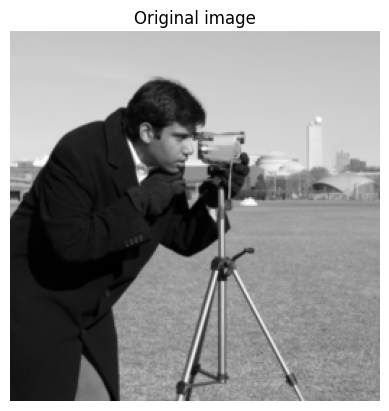

In [79]:
cameraman = ImageFitting(256)

plt.imshow(cameraman.img, cmap='grey')
plt.axis('off')
plt.title('Original image')
plt.show()

### CONFIG

In [80]:
def img_summary_function(model, coords, model_output, ground_truth, step, loss):  # This function is used to represent training process
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].imshow(model_output.cpu().view(256,256).detach().numpy(), cmap='grey')
    axs[0].axis('off')
    axs[0].set_title('Trained image', fontsize=8)

    axs[1].imshow(ground_truth.cpu().view(256,256).detach().numpy(), cmap='grey')
    axs[1].axis('off')
    axs[1].set_title('Original image', fontsize=8)

    plt.suptitle(f"Step {step}, Total loss {loss:.6f}", y=0.95)
    plt.show()

In [81]:
IN_FEATURES_IMG = 2
OUT_FEATURES_IMG = 1
HIDDEN_FEATURES_IMG = 256
HIDDEN_LAYERS_IMG = 3

NUM_EPOCHS_IMG = 1000
SUMMARY_EPOCHS_IMG = 250
LR_IMG = 1e-4

image_loader = DataLoader(cameraman, batch_size=1, pin_memory=True)

### ReLU Based MLP

Let's start with simple ReLU based MLP

In [82]:
model_mlp_img = Based_MLP(
    in_features=IN_FEATURES_IMG,
    out_features=OUT_FEATURES_IMG,
    hidden_features=HIDDEN_FEATURES_IMG,
    hidden_layers=HIDDEN_LAYERS_IMG
).to(DEVICE)

model_mlp_img

Based_MLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=1, bias=True)
  )
)

In [33]:
def mse_loss_wrapper(coords, y_pred, y_true):  # Mse loss doesn't depend on coordinates
    return F.mse_loss(y_pred, y_true)

  0%|          | 0/1000 [00:00<?, ?it/s]

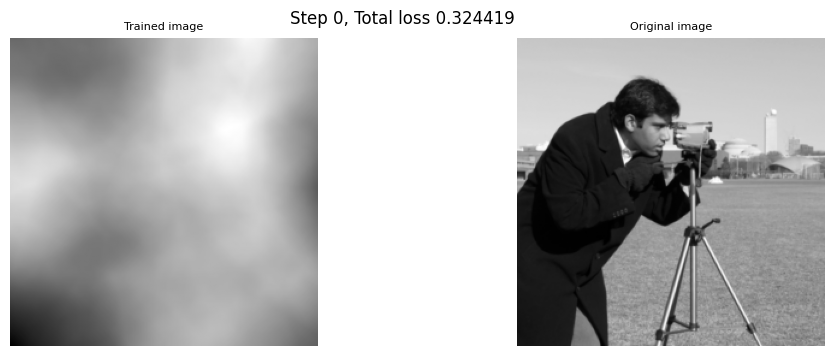

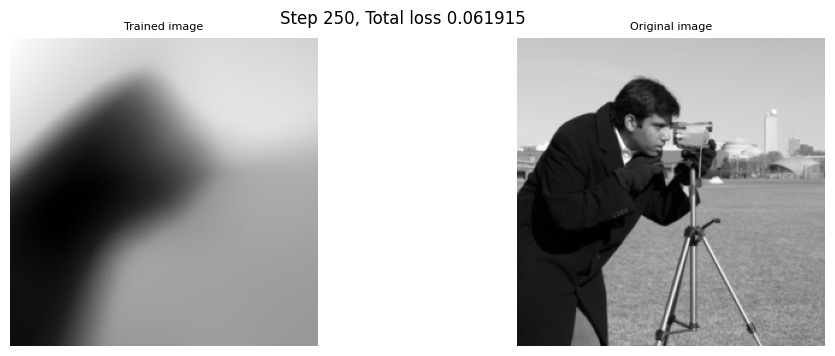

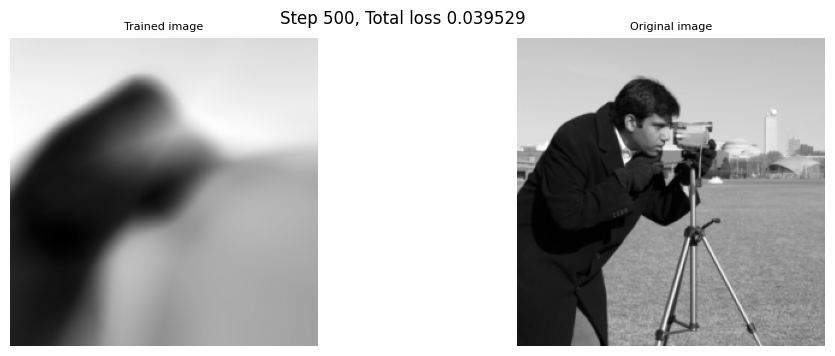

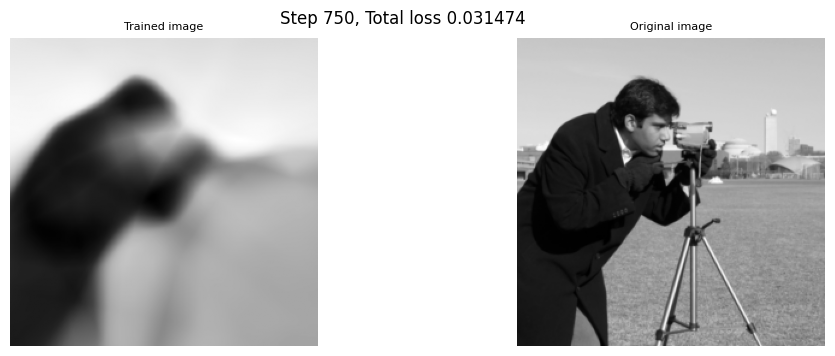

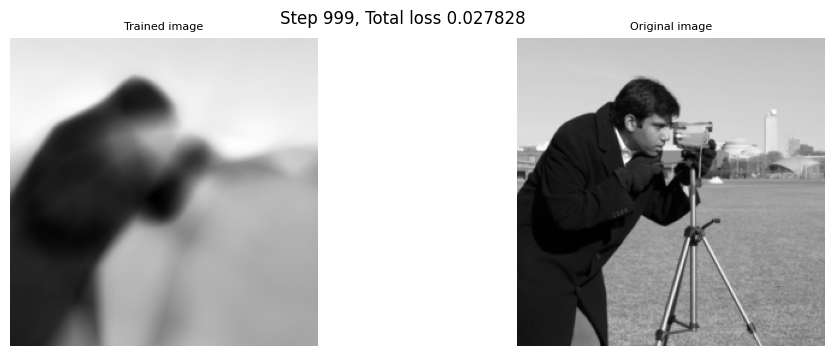

In [83]:
train(
    model=model_mlp_img,
    loss_fn=mse_loss_wrapper,
    loader=image_loader,
    device=DEVICE,
    num_epochs=NUM_EPOCHS_IMG,
    lr=LR_IMG,
    summary_epochs=SUMMARY_EPOCHS_IMG,
    summary_fn=img_summary_function
)

### SIREN

And now let's try SIREN

In [84]:
model_siren_img = Siren(
    in_features=IN_FEATURES_IMG,
    out_features=OUT_FEATURES_IMG,
    hidden_features=HIDDEN_FEATURES_IMG,
    hidden_layers=HIDDEN_LAYERS_IMG,
    outermost_linear=True
).to(DEVICE)

model_siren_img

Siren(
  (net): Sequential(
    (0): SineLayer(
      (linear): Linear(in_features=2, out_features=256, bias=True)
    )
    (1): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (2): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (3): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)

  0%|          | 0/1000 [00:00<?, ?it/s]

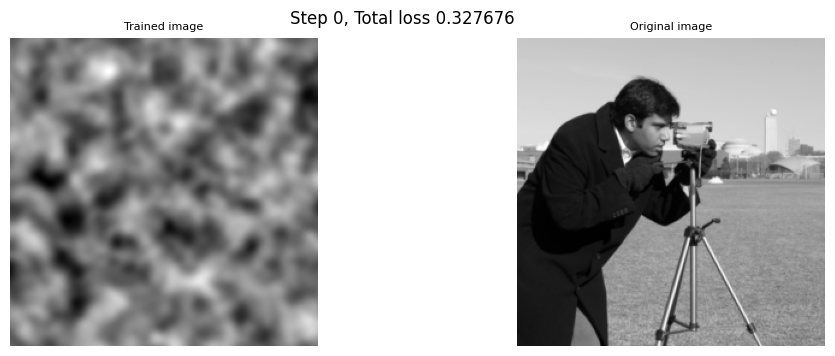

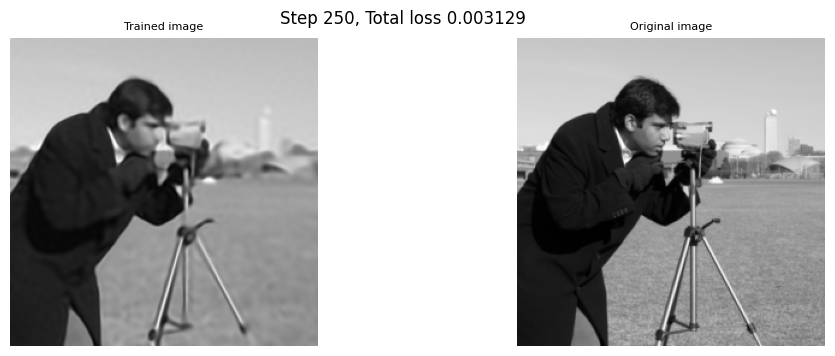

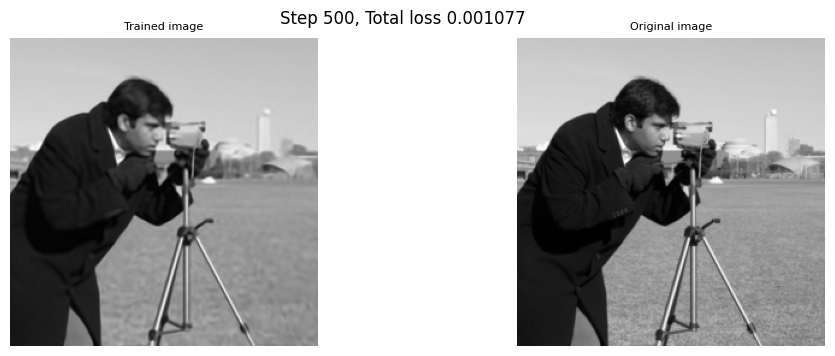

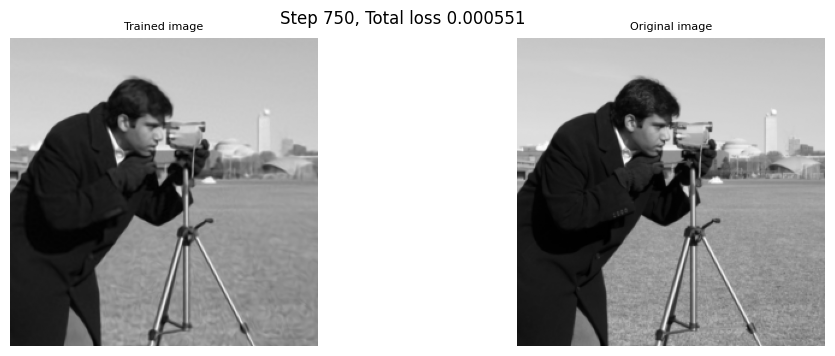

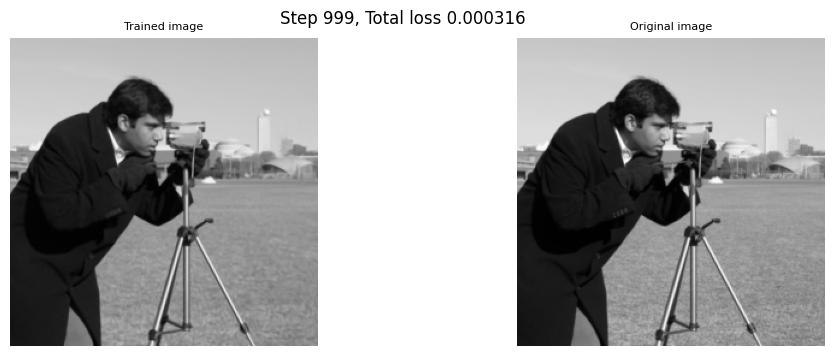

In [85]:
train(
    model=model_siren_img,
    loss_fn=mse_loss_wrapper,
    loader=image_loader,
    device=DEVICE,
    num_epochs=NUM_EPOCHS_IMG,
    lr=LR_IMG,
    summary_epochs=SUMMARY_EPOCHS_IMG,
    summary_fn=img_summary_function
)

## Audio fitting

Let’s train the network to represent an audio signal. Our neural function is now one-dimensional, $\Phi: \mathbb{R}\to\mathbb{R}$. The loss has the same form as in the image-fitting case:

**Loss function**

$$
\mathcal{L}_{\text{audio}}
=
\sum_{t\in T}\bigl\|\Phi(t)-\mathrm{Audio}_t\bigr\|.
$$

Here, $T$ is the set of available time samples, and $\mathrm{Audio}$ is the ground-truth signal we’re trying to match.

In our notation:

* $x$ — time index (frame)
* $a(x)$ — audio signal at time $x$
* $C$ — the norm of the difference
* $\Omega$ — the set of all frames (time samples)


In [37]:
class AudioFile(torch.utils.data.Dataset):
    def __init__(self, filename):
        self.rate, self.data = wavfile.read(filename)
        self.data = self.data.astype(np.float32)
        self.timepoints = get_mgrid(len(self.data), 1)

        # Average channels if we have several
        if len(self.data.shape) > 1:
            self.data = np.mean(self.data, axis=1)

    def get_num_samples(self):
        return self.timepoints.shape[0]

    def __len__(self):
        return 1

    def __getitem__(self, idx):
        amplitude = self.data
        scale = np.max(np.abs(amplitude))
        amplitude = (amplitude / scale)
        amplitude = torch.Tensor(amplitude).view(-1, 1)
        return self.timepoints, amplitude

Here is the audio that we will try to learn:

In [38]:
random_audio = AudioFile('mozart.wav')

Audio(random_audio[0][1].squeeze().numpy(), rate=random_audio.rate)

### CONFIG

In [39]:
def audio_summary_function(model, coords, model_output, ground_truth, step, loss):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].plot(coords.squeeze().detach().cpu().numpy(),model_output.squeeze().detach().cpu().numpy())
    axs[0].axis('off')
    axs[0].set_title('Trained sound', fontsize=8)

    axs[1].plot(coords.squeeze().detach().cpu().numpy(),ground_truth.squeeze().detach().cpu().numpy())
    axs[1].axis('off')
    axs[1].set_title('Original sound', fontsize=8)

    plt.suptitle(f"Step {step}, Total loss {loss:.6f}", y=0.95)
    plt.show()

Let's define architecture for our nets. As this audio signal has a much higer spatial frequency on the range of -1 to 1, we increase the  𝜔0  in the first layer of siren.

In [91]:
IN_FEATURES_AUD = 1
OUT_FEATURES_AUD = 1
HIDDEN_FEATURES_AUD = 256
HIDDEN_LAYERS_AUD = 3
FIRST_OMEGA_0_AUD = 3000

NUM_EPOCHS_AUD = 10000
SUMMARY_EPOCHS_AUD = 750
LR_AUD = 1e-4

sound_loader = DataLoader(random_audio, shuffle=False, batch_size=1, pin_memory=True, num_workers=0)

### ReLU Based MLP

In [92]:
model_mlp_sound = Based_MLP(
    in_features=IN_FEATURES_AUD,
    out_features=OUT_FEATURES_AUD,
    hidden_features=HIDDEN_FEATURES_AUD,
    hidden_layers=HIDDEN_LAYERS_AUD,
).to(DEVICE)


model_mlp_sound

Based_MLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=1, bias=True)
  )
)

  0%|          | 0/10000 [00:00<?, ?it/s]

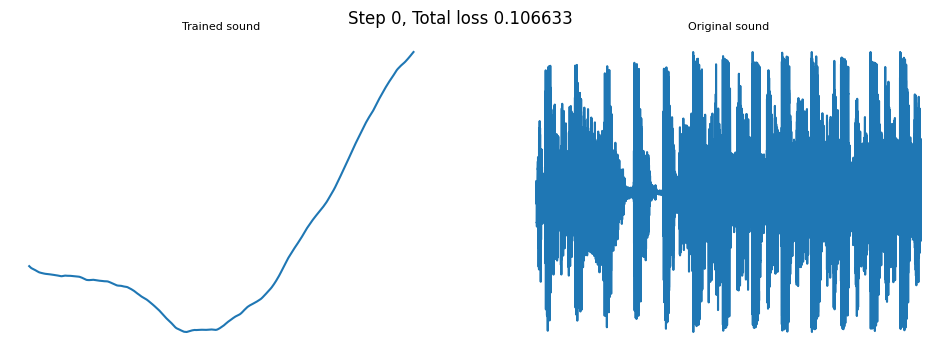

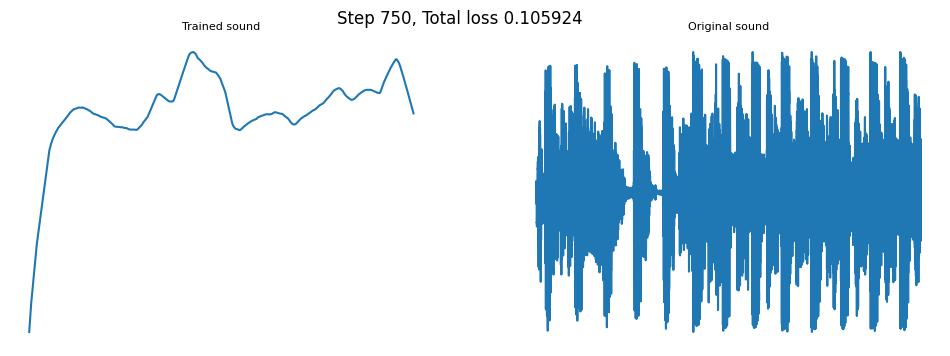

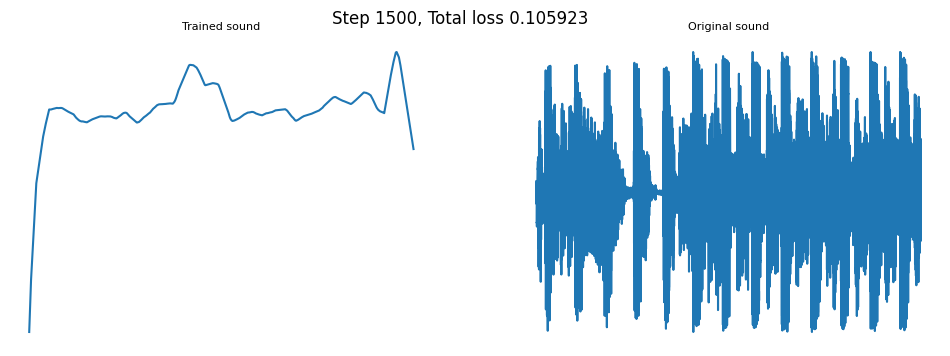

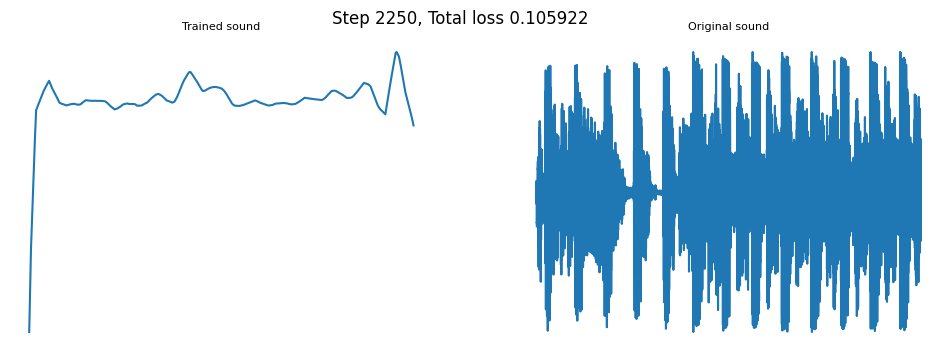

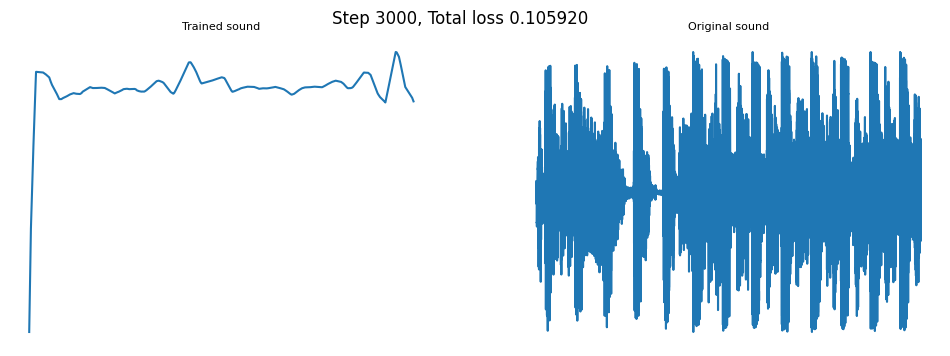

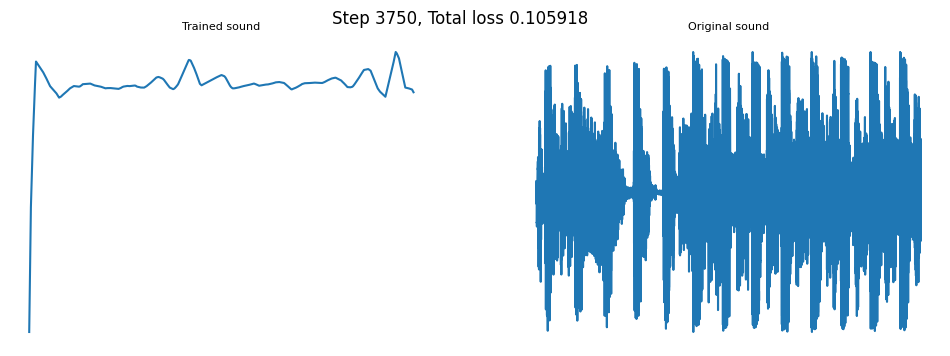

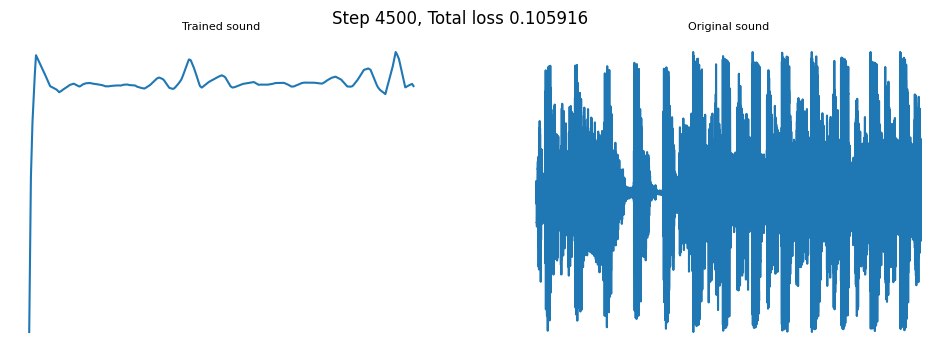

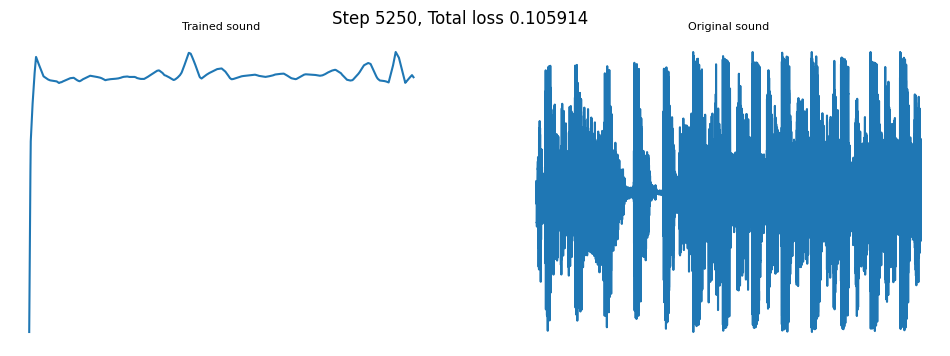

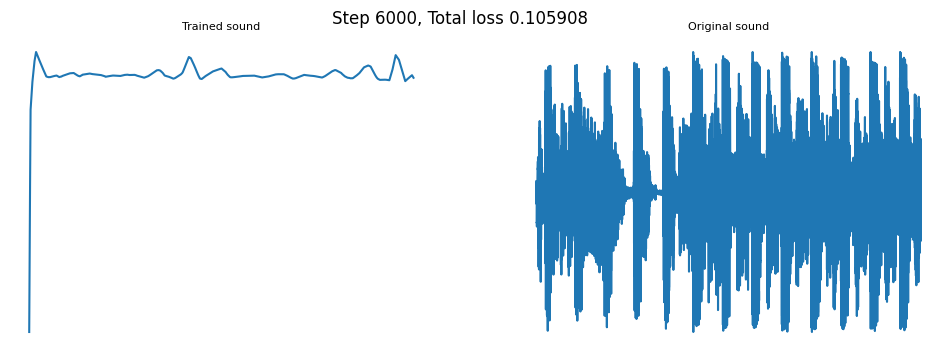

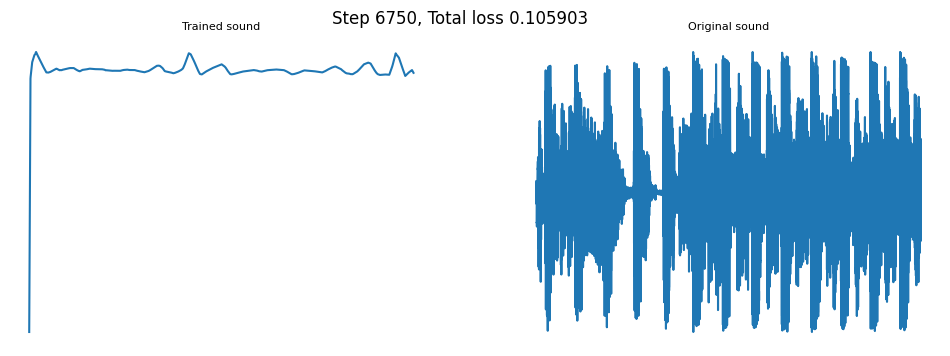

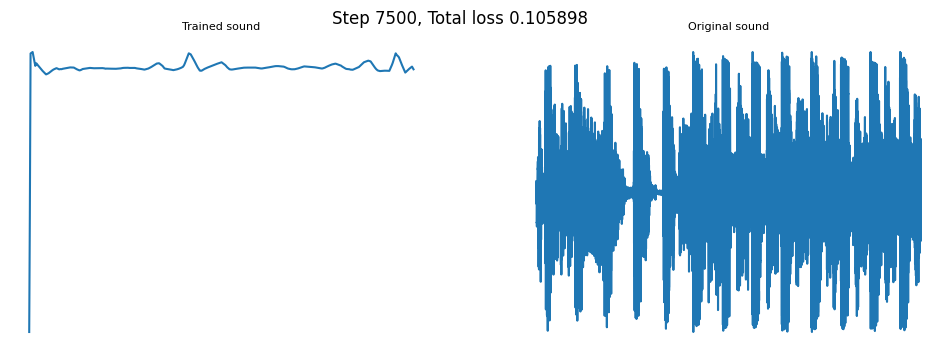

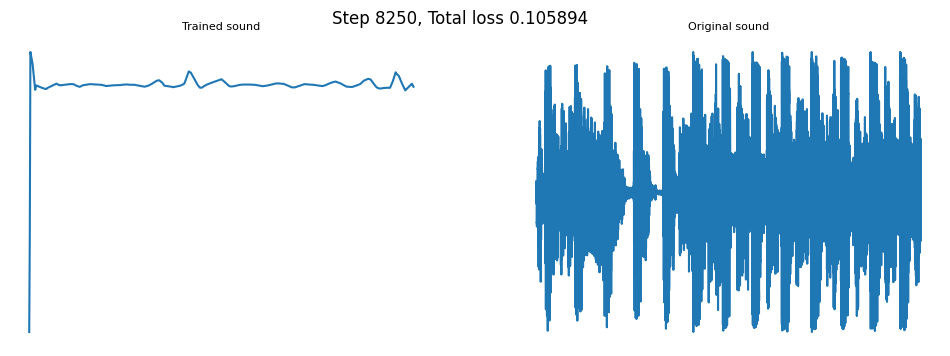

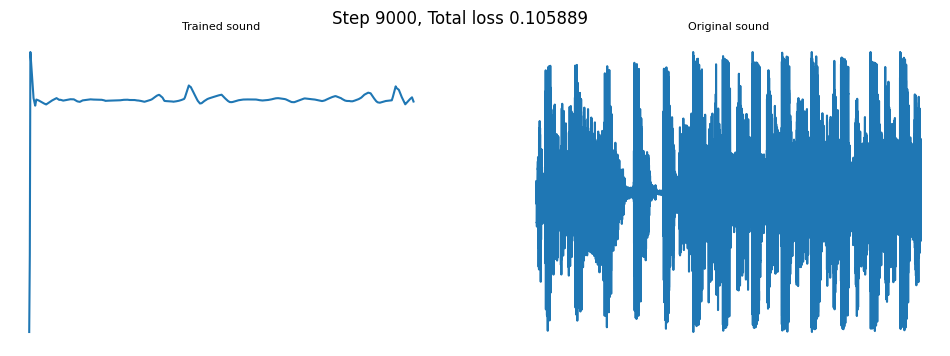

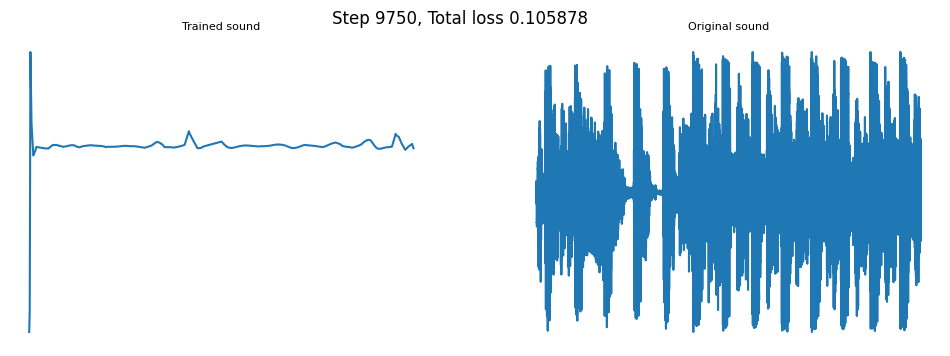

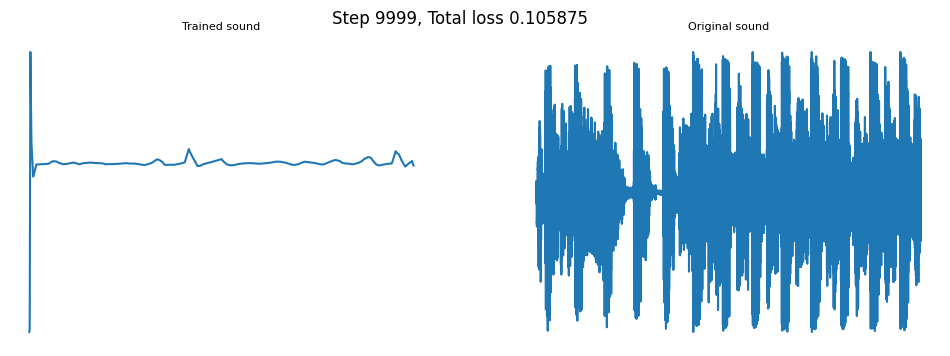

In [93]:
train(
    model=model_mlp_sound,
    loss_fn=mse_loss_wrapper,
    loader=sound_loader,
    device=DEVICE,
    num_epochs=NUM_EPOCHS_AUD,
    lr=LR_AUD,
    summary_epochs=SUMMARY_EPOCHS_AUD,
    summary_fn=audio_summary_function
)

In [95]:
model_input, ground_truth = next(iter(sound_loader))
final_mlp_output, coords_mlp = model_mlp_sound(model_input.to(DEVICE))

Audio(final_mlp_output.cpu().detach().squeeze().numpy(),rate=random_audio.rate)

### SIREN

In [88]:
model_siren_sound = Siren(
    in_features=IN_FEATURES_AUD,
    out_features=OUT_FEATURES_AUD,
    hidden_features=HIDDEN_FEATURES_AUD,
    hidden_layers=HIDDEN_LAYERS_AUD,
    first_omega_0=FIRST_OMEGA_0_AUD,
    outermost_linear=True
).to(DEVICE)


model_siren_sound

Siren(
  (net): Sequential(
    (0): SineLayer(
      (linear): Linear(in_features=1, out_features=256, bias=True)
    )
    (1): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (2): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (3): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)

  0%|          | 0/3000 [00:00<?, ?it/s]

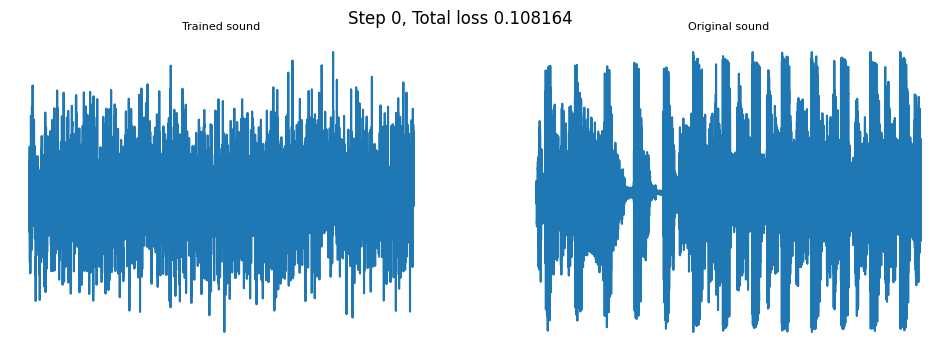

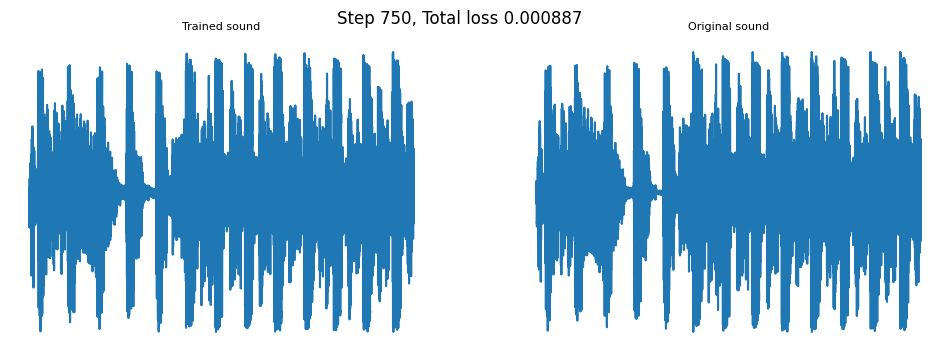

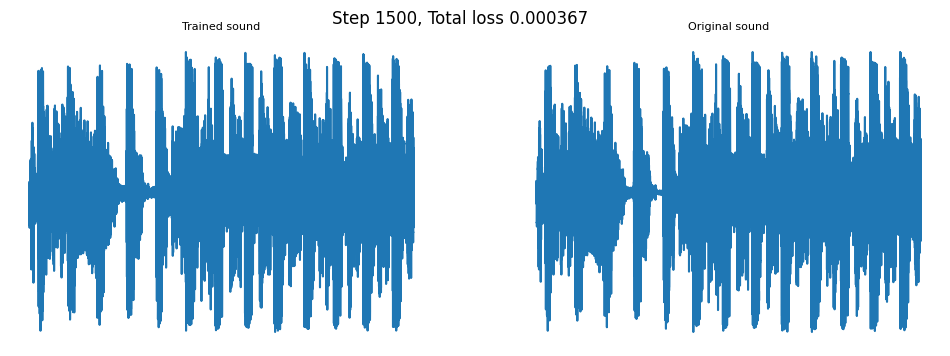

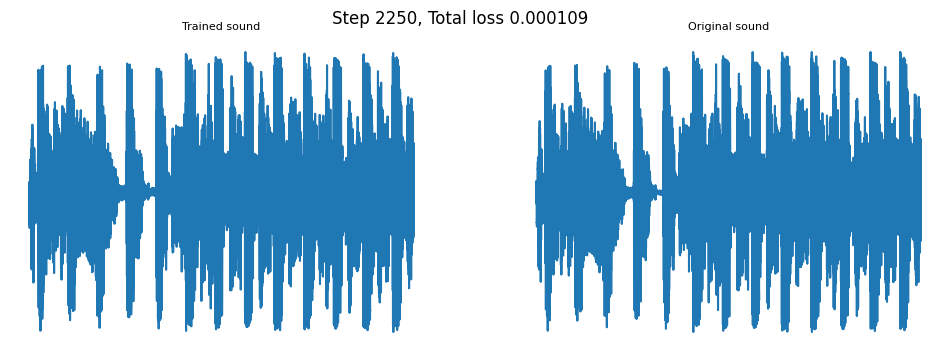

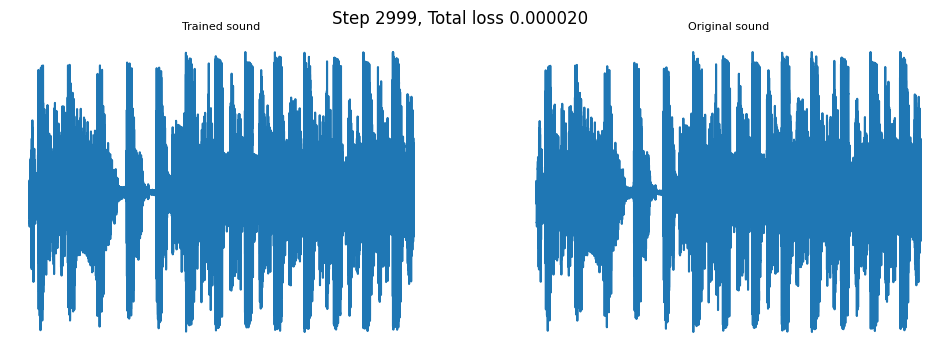

In [89]:
train(
    model=model_siren_sound,
    loss_fn=mse_loss_wrapper,
    loader=sound_loader,
    device=DEVICE,
    num_epochs=NUM_EPOCHS_AUD,
    lr=LR_AUD,
    summary_epochs=SUMMARY_EPOCHS_AUD,
    summary_fn=audio_summary_function
)

In [90]:
model_input, ground_truth = next(iter(sound_loader))
final_siren_output, coords_siren = model_siren_sound(model_input.to(DEVICE))

Audio(final_siren_output.cpu().detach().squeeze().numpy(),rate=random_audio.rate)

# SDF

In this section, we’ll represent a Signed Distance Function (SDF) with our networks.

A **Signed Distance Function (SDF)** returns the shortest distance from a point in space to the surface of a shape. The sign indicates whether the point is inside (negative), on (zero), or outside (positive) the shape.

For example, the SDF of a **sphere** of radius $r$ centered at the origin is

$$
f(\mathbf{p}) = \|\mathbf{p}\| - r,
$$

where $\mathbf{p}$ is any point in $\mathbb{R}^3$. This function is

* **zero** on the sphere’s surface,
* **negative** inside the sphere,
* **positive** outside the sphere.

SDFs are widely used in computer graphics—especially in ray marching and procedural modeling—because they provide a simple, efficient way to represent complex geometry.

Now our network’s domain is $\mathbb{R}^3 \to \mathbb{R}$. The loss becomes more involved:

$$
\begin{aligned}
\mathcal{L}_{\rm sdf}
&=
\int_{\Omega}\bigl\|\lvert\nabla_{\mathbf{x}}\Phi(\mathbf{x})\rvert - 1\bigr\|\;dx
\;+\;
\int_{\Omega_0}\Bigl\lVert\Phi(\mathbf{x})\Bigr\rVert
\;+\;\Bigl(1 - \langle\nabla_{\mathbf{x}}\Phi(\mathbf{x}),\,\mathbf{n}(\mathbf{x})\rangle\Bigr)\;dx\\
&\quad
+\;\int_{\Omega\setminus\Omega_0}\exp\bigl(-\alpha\,\lvert\Phi(\mathbf{x})\rvert\bigr)\;dx,
\end{aligned}
$$

where:

* $\mathbf{x}$ — a point in $\mathbb{R}^3$.
* $\Omega$ — the region over which we want our SDF defined.
* $\Omega_0$ — the object’s surface.
* $\mathbf{n}(\mathbf{x})$ — the unit normal at $\mathbf{x}\in\Omega_0$.
* $\alpha$ — a large constant ($\alpha\gg1$).

1. The first term enforces $\lvert\nabla\Phi\rvert\approx1$, since the gradient magnitude of any true SDF is 1.
2. The second term drives $\Phi(\mathbf{x})$ toward zero on the surface and aligns $\nabla\Phi(\mathbf{x})$ with the surface normal $\mathbf{n}(\mathbf{x})$.
3. The third term penalizes nonzero values outside the surface, pushing $\Phi$ away from zero in the exterior.

In practice, we sample half of each training batch from the object’s surface $\Omega_0$ and the other half uniformly at random from $\Omega=[-1,1]^3$.


In [47]:
def calc_gradient(y, x, grad_outputs=None):
    """
    Compute the gradient of y with respect to x, retaining the computation graph.
    """
    if grad_outputs is None:
        grad_outputs = torch.ones_like(y)
    grad = torch.autograd.grad(y, [x], grad_outputs=grad_outputs, create_graph=True)[0]
    return grad

In [48]:
def sdf_loss(coords, model_output, gt):
   """
   Combine surface, exterior, normal, and Eikonal constraints into a single SDF loss.
   """
   gt_sdf = gt['sdf']
   gt_normals = gt['normals']

   gradient = calc_gradient(model_output, coords)

   # Wherever boundary_values is not equal to zero, we interpret it as a boundary constraint.

   # Zero‐boundary constraint on‐surface, exponential push off‐surface
   sdf_constraint = torch.where(gt_sdf != -1, model_output, torch.zeros_like(model_output))
   inter_constraint = torch.where(gt_sdf != -1, torch.zeros_like(model_output), torch.exp(-1e2 * torch.abs(model_output)))

   # Enforce gradient alignment with true normals on‐surface
   normal_constraint = torch.where(gt_sdf != -1, 1 - F.cosine_similarity(gradient, gt_normals, dim=-1)[..., None],
                                 torch.zeros_like(gradient[..., :1]))

   # Eikonal term: norm of gradients should be equal to 1 everywhere
   grad_constraint = torch.abs(gradient.norm(dim=-1) - 1)
   return torch.abs(sdf_constraint).mean() * 3e3 + \
          inter_constraint.mean() * 1e2 + \
          normal_constraint.mean() * 1e2 + \
          grad_constraint.mean() * 5e1

This dataset first recenters and scales a raw point cloud so that all points lie within the $-1,1$ cube (optionally preserving the original aspect ratio). At each training step it randomly selects a fixed number of “on‐surface” points from the cloud (with SDF label 0) and pairs them with the same number of uniformly sampled “off‐surface” points in the cube (SDF label –1). Normals for on‐surface samples are taken from the input data, while off‐surface normals are set to a placeholder.

In [96]:
class PointCloud(Dataset):
    """
    Normalize a 3D point cloud into [-1,1] and sample mixed batches of on- and off-surface points.
    """

    def __init__(self, point_cloud, on_surface_points, keep_aspect_ratio=True):
        super().__init__()

        coords = point_cloud[:, :3]
        self.normals = point_cloud[:, 3:]

        # Reshape point cloud such that it lies in bounding box of (-1, 1) (distorts geometry, but makes for high
        # sample efficiency)
        coords -= np.mean(coords, axis=0, keepdims=True)
        if keep_aspect_ratio:
            coord_max = np.amax(coords)
            coord_min = np.amin(coords)
        else:
            coord_max = np.amax(coords, axis=0, keepdims=True)
            coord_min = np.amin(coords, axis=0, keepdims=True)

        self.coords = (coords - coord_min) / (coord_max - coord_min)
        self.coords -= 0.5
        self.coords *= 2.

        self.on_surface_points = on_surface_points

    def __len__(self):
        return self.coords.shape[0] // self.on_surface_points

    def __getitem__(self, idx):
        """
        Sample on-surface points from the cloud and random off-surface points,
        then assemble their normals and SDF labels.
        """
        point_cloud_size = self.coords.shape[0]

        off_surface_samples = self.on_surface_points  # **2
        total_samples = self.on_surface_points + off_surface_samples

        # Random coords
        rand_idcs = np.random.choice(point_cloud_size, size=self.on_surface_points)

        # On-surface sampling
        on_surface_coords = self.coords[rand_idcs, :]
        on_surface_normals = self.normals[rand_idcs, :]

        # Off-surface sampling
        off_surface_coords = np.random.uniform(-1, 1, size=(off_surface_samples, 3))
        off_surface_normals = np.ones((off_surface_samples, 3)) * -1

        # Signed distance: 0 for on-surface, -1 for off-surface
        sdf = np.zeros((total_samples, 1))  # on-surface = 0
        sdf[self.on_surface_points:, :] = -1  # off-surface = -1

        coords = np.concatenate((on_surface_coords, off_surface_coords), axis=0)
        normals = np.concatenate((on_surface_normals, off_surface_normals), axis=0)

        coords_tensor = torch.from_numpy(coords).float()

        return coords_tensor, \
            {
                'sdf': torch.from_numpy(sdf).float(),
                'normals': torch.from_numpy(normals).float(),
                'coords': coords_tensor
            }

In [97]:
import open3d as o3d

def obj_to_dense_pointcloud_with_normals(obj_path: str, n_points: int = 100000):
    """
    Load a 3D mesh and generate a dense uniform point cloud with normals.
    """
    mesh = o3d.io.read_triangle_mesh(obj_path)
    if mesh.is_empty():
        raise ValueError(f"Can't get mash from {obj_path}")

    mesh.compute_vertex_normals()

    pcd = mesh.sample_points_uniformly(number_of_points=n_points)
    pcd.estimate_normals()

    pts = np.asarray(pcd.points)
    nml = np.asarray(pcd.normals)

    return np.hstack([pts, nml])

In [51]:
%%bash
wget https://raw.githubusercontent.com/alecjacobson/common-3d-test-models/master/data/spot.obj

--2026-03-12 12:02:46--  https://raw.githubusercontent.com/alecjacobson/common-3d-test-models/master/data/spot.obj
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 330624 (323K) [text/plain]
Saving to: ‘spot.obj’

     0K .......... .......... .......... .......... .......... 15% 4.53M 0s
    50K .......... .......... .......... .......... .......... 30% 4.36M 0s
   100K .......... .......... .......... .......... .......... 46% 4.82M 0s
   150K .......... .......... .......... .......... .......... 61% 5.34M 0s
   200K .......... .......... .......... .......... .......... 77% 4.43M 0s
   250K .......... .......... .......... .......... .......... 92% 4.89M 0s
   300K .......... .......... ..                              100% 8.63M=0.06s

2026-03-12 12:02:46

In [52]:
spot_points_and_normals = obj_to_dense_pointcloud_with_normals('spot.obj', n_points=1000000)

In [53]:
spot_point_cloud = PointCloud(spot_points_and_normals, 100000, True)

In [54]:
sdf_loader = DataLoader(spot_point_cloud, batch_size=1, pin_memory=True)

**Rendering**:
The rendering pipeline shoots camera rays in tiles across the image, sphere‐traces each ray against an implicit signed‐distance function to find surface intersections, estimates point normals via SDF gradients, and finally shades visible points by the angle to a light direction. Tiling keeps memory use in check while batching SDF evaluations for efficiency.

In [55]:
import math

def get_camera_rays(tile_dims, full_dims, fov, cam_origin, cam_target, up):
    """
    Compute ray origins and directions for a given image tile.
    Look-At parametrization.
    """
    tile_h, tile_w = tile_dims
    H, W = full_dims
    forward = F.normalize(cam_target - cam_origin, dim=0)
    right = F.normalize(torch.cross(forward, up), dim=0)
    true_up = torch.cross(right, forward)

    aspect = W / H
    screen_h = 2 * math.tan(fov / 2)
    screen_w = screen_h * aspect

    y_indices = torch.arange(0, tile_h, device=cam_origin.device) + get_camera_rays.y0
    x_indices = torch.arange(0, tile_w, device=cam_origin.device) + get_camera_rays.x0
    ys, xs = torch.meshgrid(y_indices, x_indices, indexing='ij')

    u = (xs + 0.5) / W - 0.5
    v = 0.5 - (ys + 0.5) / H
    u = u * screen_w
    v = v * screen_h

    dirs = forward[None, None, :] + u[..., None] * right[None, None, :] + v[..., None] * true_up[None, None, :]
    dirs = F.normalize(dirs.reshape(-1, 3), dim=-1)
    origins = cam_origin.expand(dirs.shape)
    return origins, dirs

get_camera_rays.y0 = 0
get_camera_rays.x0 = 0

def sphere_trace(model, origins, directions,
                 max_steps=100, epsilon=1e-4, max_dist=10.0,
                 sdf_batch_size=65536, device='cuda'):
    """
    March rays through the SDF via sphere tracing to find surface hits.
    """
    N = origins.shape[0]
    origins = origins.to(device)
    directions = directions.to(device)
    hits = torch.zeros(N, dtype=torch.bool, device=device)

    inv_d = torch.where(directions != 0,
                        1.0 / directions,
                        torch.zeros_like(directions))
    t1 = (-1.0 - origins) * inv_d
    t2 = ( 1.0 - origins) * inv_d
    t_min = torch.max(torch.min(t1, t2), dim=1).values
    t_max = torch.min(torch.max(t1, t2), dim=1).values
    mask_parallel_outside = (directions == 0) & ((origins < -1.0) | (origins > 1.0))
    no_intersect = mask_parallel_outside.any(dim=1)
    t_min[no_intersect] = float('inf')
    t_max[no_intersect] = float('-inf')
    t_enter = t_min
    t_exit  = t_max

    t_exit_clamped = torch.min(t_exit, torch.full_like(t_exit, max_dist))
    t = torch.clamp(t_enter, min=0.0, max=max_dist)

    for _ in range(max_steps):
        alive = (~hits) & (t < t_exit_clamped)
        if not alive.any():
            break
        pts = origins[alive] + directions[alive] * t[alive].unsqueeze(-1)

        dist_vals = []
        for i in range(0, pts.shape[0], sdf_batch_size):
            chunk = pts[i:i + sdf_batch_size]
            with torch.no_grad():
                d = model(chunk)
            dist_vals.append(d)
        dist = torch.cat(dist_vals, dim=0)

        t_alive = t[alive] + dist
        new_hits = (dist.abs() < epsilon) & (t_alive <= t_exit_clamped[alive])

        hits_idx = torch.nonzero(alive, as_tuple=False).squeeze(1)
        hits[hits_idx[new_hits]] = True
        t[alive] = t_alive

        t = torch.where(t > t_exit_clamped,
                        torch.full_like(t, max_dist),
                        t)

    return t, hits

def estimate_normals(model, points, eps=1e-3,
                     sdf_batch_size=65536, device='cuda'):
    """
    Compute surface normals by backpropagating through the SDF.
    """
    normals = []
    for i in range(0, points.shape[0], sdf_batch_size):
        pts = points[i:i + sdf_batch_size].clone().to(device)
        pts.requires_grad_(True)
        d = model(pts)
        grads = torch.autograd.grad(d.sum(), pts)[0]
        normals.append(F.normalize(grads, dim=-1).cpu())
    return torch.cat(normals, dim=0)

def render_sdf_shaded(model, width, height, fov,
                      cam_origin, cam_target, up,
                      tile_size=64, max_steps=100,
                      epsilon=1e-4, max_dist=10.0,
                      sdf_batch_size=65536,
                      light_dir=None,
                      device='cuda'):
    """
    Render a shaded image by tracing rays, intersecting an SDF, and applying simple lighting.
    """
    image = torch.zeros((height, width), dtype=torch.float32)
    if light_dir is None:
        light_dir = F.normalize(torch.tensor([1., 1., 1.], device=device), dim=0)
    else:
        light_dir = F.normalize(light_dir, dim=0)

    for y0 in range(0, height, tile_size):
        for x0 in range(0, width, tile_size):
            Ht = min(tile_size, height - y0)
            Wt = min(tile_size, width - x0)
            get_camera_rays.y0, get_camera_rays.x0 = y0, x0
            origins, dirs = get_camera_rays((Ht, Wt), (height, width), fov,
                                            cam_origin, cam_target, up)

            t_flat, hits = sphere_trace(model, origins, dirs,
                                        max_steps, epsilon,
                                        max_dist, sdf_batch_size,
                                        device)
            pts = origins + dirs * t_flat.unsqueeze(-1)
            normals = estimate_normals(model, pts, eps=epsilon,
                                       sdf_batch_size=sdf_batch_size,
                                       device=device)
            shading = torch.clamp((normals.to(device) * light_dir).sum(-1), min=0)

            tile = shading.cpu().reshape(Ht, Wt)
            tile[~hits.reshape(Ht, Wt).cpu()] = 0
            image[y0:y0+Ht, x0:x0+Wt] = tile

    return image


In [56]:
class SirenSDFWrapper(torch.nn.Module):
    """
    Simple wrapper around a SIREN model to reshape its output into a flat vector
    while preserving gradient flow for downstream normal estimation.
    """
    def __init__(self, siren_model):
        super().__init__()
        self.siren = siren_model
    def forward(self, x):
        output, _ = self.siren(x)
        return output.view(-1)

def render_image_with_model(model: nn.Module):
    model.eval()
    siren = SirenSDFWrapper(model)
    cam_o = torch.tensor([-1.5, 0.0, -3.0]).to(DEVICE)
    cam_t = torch.tensor([0.0, 0.0, 0.0]).to(DEVICE)
    up   = torch.tensor([0.0, -1.0, 0.0]).to(DEVICE)
    light_dir = torch.tensor([0.3, 1.0, -1.0]).to(DEVICE)
    siren.eval()
    img = render_sdf_shaded(
        siren, 512, 512, math.radians(60),
        cam_o, cam_t, up,
        tile_size=64, max_steps=100,
        epsilon=1e-4, max_dist=10.0,
        sdf_batch_size=65536,
        light_dir=light_dir,
        device=DEVICE
    )
    model.train()

    return img.numpy()


In [57]:
def sdf_summary_function(model, coords, model_output, ground_truth, step, loss):
    img = render_image_with_model(model)
    plt.imshow(img, cmap='gray', origin='lower')
    plt.axis('off')
    plt.suptitle(f"Step {step}, Total loss {loss:.6f}", y=0.95)
    plt.show()

### SIREN

In [58]:
model_siren_sdf = Siren(
    in_features=3,
    out_features=1,
    hidden_features=256,
    hidden_layers=3,
    outermost_linear=True
).to(DEVICE)


model_siren_sdf

Siren(
  (net): Sequential(
    (0): SineLayer(
      (linear): Linear(in_features=3, out_features=256, bias=True)
    )
    (1): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (2): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (3): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)

  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_250/131577828.py:11: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  right = F.normalize(torch.cross(forward, up), dim=0)


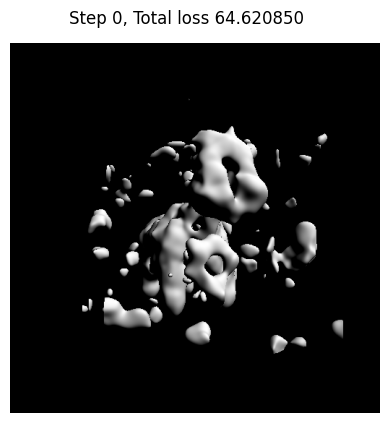

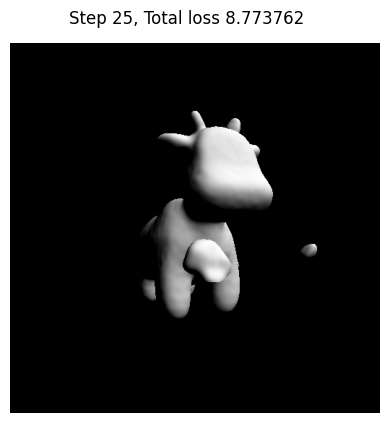

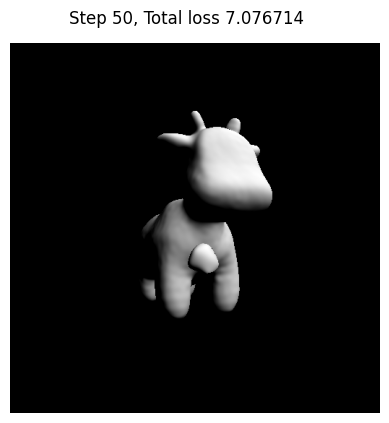

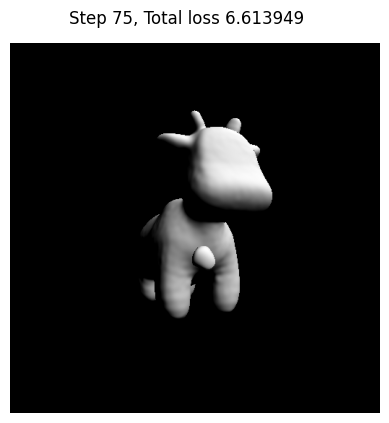

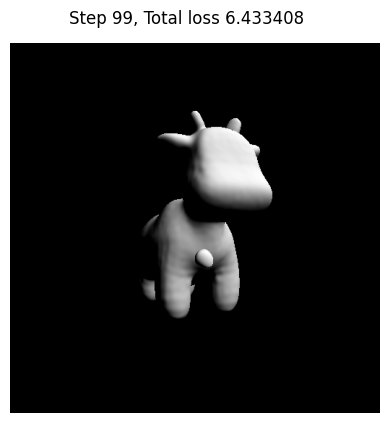

In [59]:
train(
    model_siren_sdf,
    sdf_loss,
    sdf_loader,
    DEVICE,
    100,
    1e-4,
    summary_epochs=25,
    summary_fn=sdf_summary_function
)

### ReLU based MLP

In [60]:
model_mlp_sdf = Based_MLP(
    in_features=3,
    out_features=1,
    hidden_features=256,
    hidden_layers=3
).to(DEVICE)


model_mlp_sdf

Based_MLP(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=1, bias=True)
  )
)

  0%|          | 0/100 [00:00<?, ?it/s]

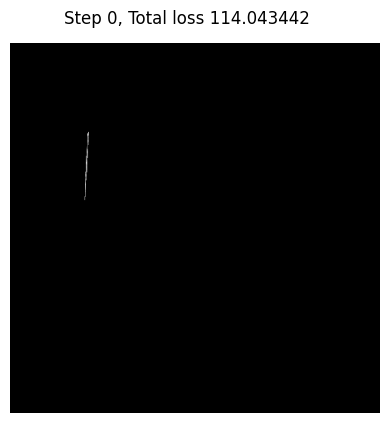

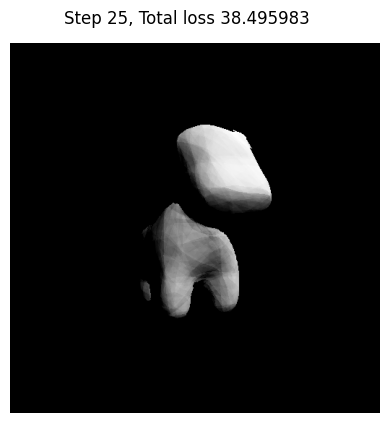

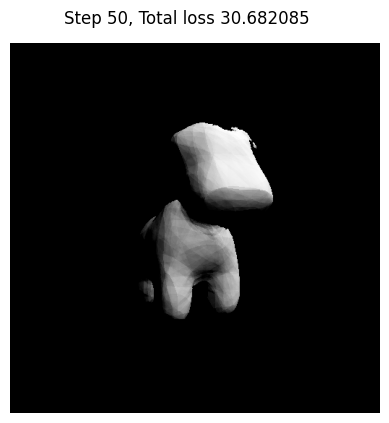

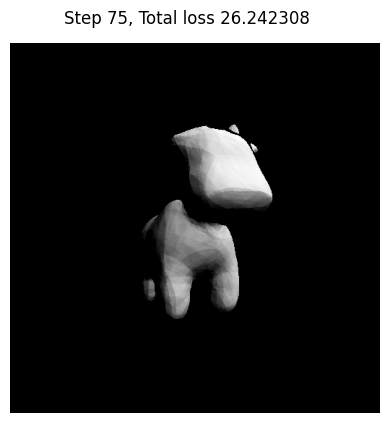

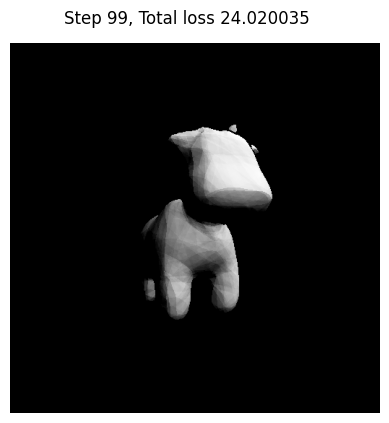

In [61]:
train(
    model_mlp_sdf,
    sdf_loss,
    sdf_loader,
    DEVICE,
    100,
    1e-4,
    summary_epochs=25,
    summary_fn=sdf_summary_function
)

# **Bonus part**

# Image inpainting

In this part we want to see what model prediction looks out of training set, lets mask some parts of the picture and see what model will predict on parts of image that it have never seen in training process.

In [62]:
class ImageFittingMasked(Dataset):
    def __init__(self, sidelength, mask):
        super().__init__()
        img = get_cameraman_tensor(sidelength)
        self.pixels = img.squeeze(0).reshape(-1, 1)
        self.coords = get_mgrid(sidelength, 2)

        if mask.shape != (sidelength, sidelength):
            raise ValueError(f"Shape of the mask {mask.shape} is not equal to ({sidelength}, {sidelength})")

        mask_bool = mask.bool().reshape(-1)
        keep_idx = (~mask_bool).nonzero(as_tuple=False).squeeze(1)
        mask_idx = (mask_bool).nonzero(as_tuple=False).squeeze(1)
        self.coords_masked = self.coords[keep_idx].clone()
        self.pixels_masked = self.pixels[keep_idx].clone()

        self.pixels[mask_idx] = 0

    def __len__(self):
        return 1

    def __getitem__(self, idx):
        if idx > 0:
            raise IndexError
        return self.coords, self.pixels, self.coords_masked, self.pixels_masked

In this experiment, the model is trained to predict only the even grid points and never sees the other points during training.

In [63]:
def train_img_masked(model, optimizer, masked_loader, device='cuda'):
    model_input_full_img, ground_truth_full_img, model_input, ground_truth = next(iter(masked_loader))
    model_input, ground_truth = model_input.to(device), ground_truth.to(device)
    model_input_full_img, ground_truth_full_img = model_input_full_img.to(device), ground_truth_full_img.to(device)

    model_output_full_image = None

    for step in tqdm(range(TOTAL_OPT_STEPS)):
        optimizer.zero_grad()

        model_output, coords = model(model_input)

        with torch.no_grad():
            model_output_full_image, _ = model(model_input_full_img)


        loss = F.mse_loss(model_output, ground_truth)

        loss.backward()
        optimizer.step()

        if not step % SUMMARY_STEPS or step == TOTAL_OPT_STEPS - 1:
            fig, axs = plt.subplots(1, 2, figsize=(12, 4))

            axs[0].imshow(model_output_full_image.cpu().view(256,256).detach().numpy(), cmap='grey')
            axs[0].axis('off')
            axs[0].set_title('Trained image', fontsize=8)

            axs[1].imshow(ground_truth_full_img.cpu().view(256,256).detach().numpy(), cmap='grey')
            axs[1].axis('off')
            axs[1].set_title('Original image', fontsize=8)

            plt.suptitle(f"Step {step}, Total loss {loss:.6f}", y=0.95)
            plt.show()

    return model_output_full_image.cpu().view(256,256).detach()

Here we create a masks to hide parts of the picture

In [64]:
IMAGE_SIZE = 256

mask = torch.zeros((256, 256))
mask[128:158, 10:40] = 1
mask[10:40, 128:158] = 1
mask[220:250, 180:210] = 1

In [65]:
masked_cameraman = ImageFittingMasked(256, mask=mask)

In [66]:
IN_FEATURES = 2
OUT_FEATURES = 1
HIDDEN_FEATURES = 256
HIDDEN_LAYERS = 3

TOTAL_OPT_STEPS = 1000
SUMMARY_STEPS = 250
LR = 1e-4

IMAGE_LOADER = DataLoader(masked_cameraman, batch_size=1, pin_memory=True)

In [67]:
model_siren_img = Siren(
    in_features=IN_FEATURES,
    out_features=OUT_FEATURES,
    hidden_features=HIDDEN_FEATURES,
    hidden_layers=HIDDEN_LAYERS,
    outermost_linear=True
).to(DEVICE)

optim_siren_img = torch.optim.Adam(params=model_siren_img.parameters(), lr=LR)

model_siren_img

Siren(
  (net): Sequential(
    (0): SineLayer(
      (linear): Linear(in_features=2, out_features=256, bias=True)
    )
    (1): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (2): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (3): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)

  0%|          | 0/1000 [00:00<?, ?it/s]

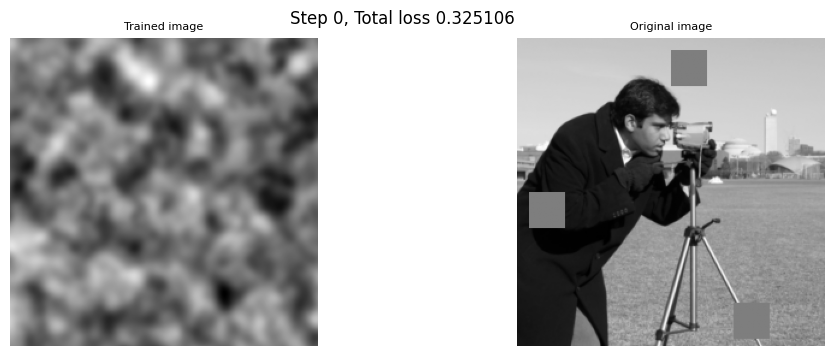

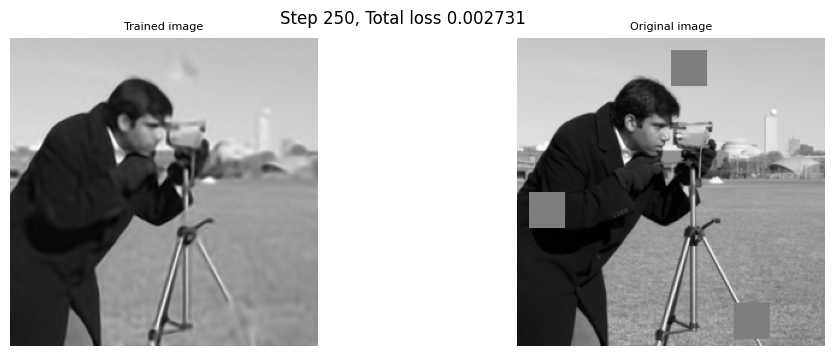

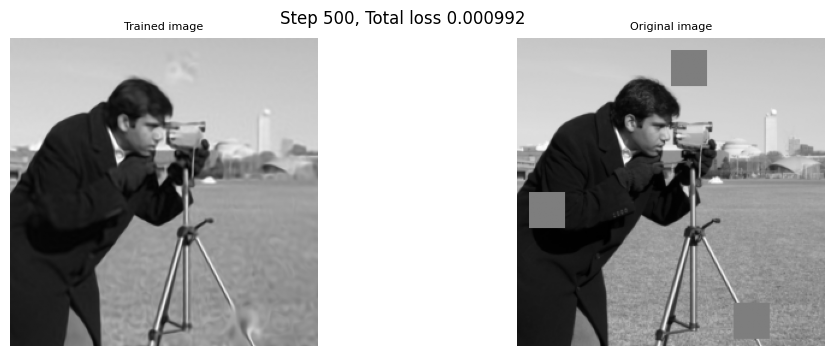

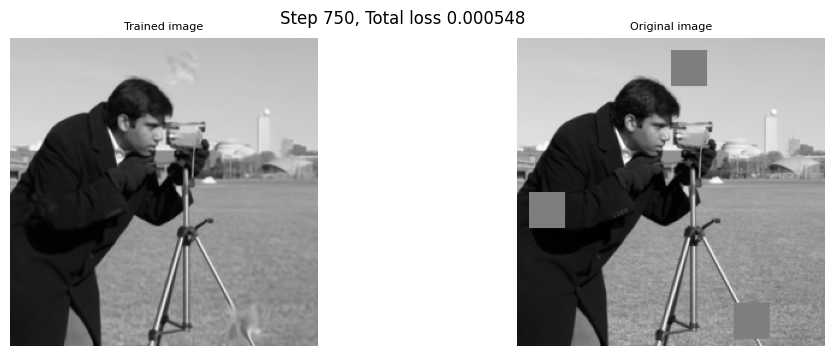

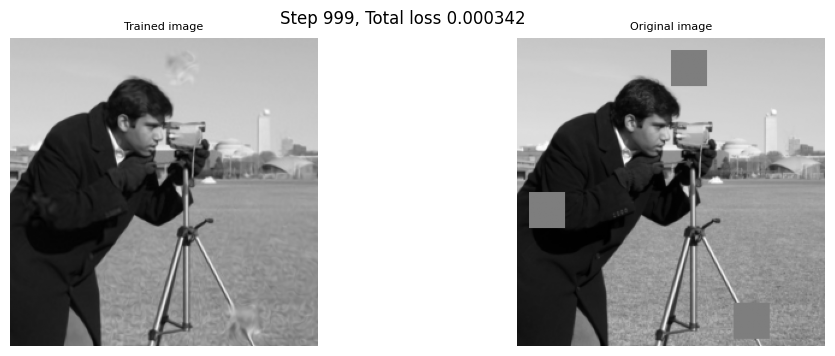

In [68]:
_ = train_img_masked(
    model=model_siren_img,
    optimizer=optim_siren_img,
    masked_loader=IMAGE_LOADER,
    device=DEVICE
)

# Super resolution with SIREN

If we already have code to train the model with masked parts of an image, why not try a super‐resolution task? We will mask every pixel with at least one odd coordinate—equivalent to a 2x downscale—and then ask the model to predict the complete image.

In [69]:
def generate_upscale_mask(size: int) -> torch.Tensor:
    mask = torch.ones((size, size), dtype=torch.uint8)
    mask[0::2, 0::2] = 0
    return mask

In [70]:
upscale_mask = generate_upscale_mask(256)

In [71]:
model_siren_img = Siren(
    in_features=IN_FEATURES,
    out_features=OUT_FEATURES,
    hidden_features=HIDDEN_FEATURES,
    hidden_layers=HIDDEN_LAYERS,
    outermost_linear=True
).to(DEVICE)

optim_siren_img = torch.optim.Adam(params=model_siren_img.parameters(), lr=LR)

  0%|          | 0/1500 [00:00<?, ?it/s]

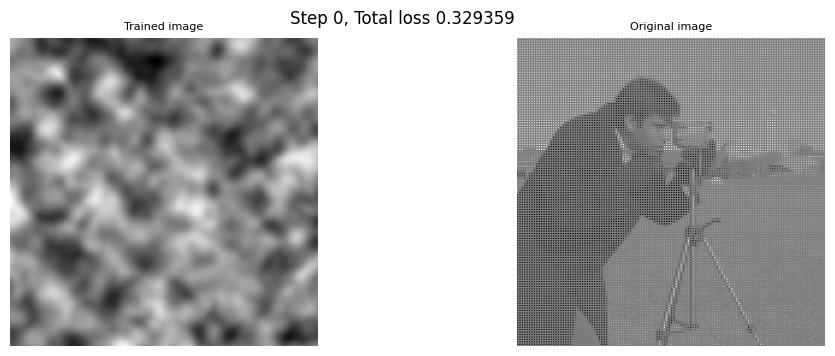

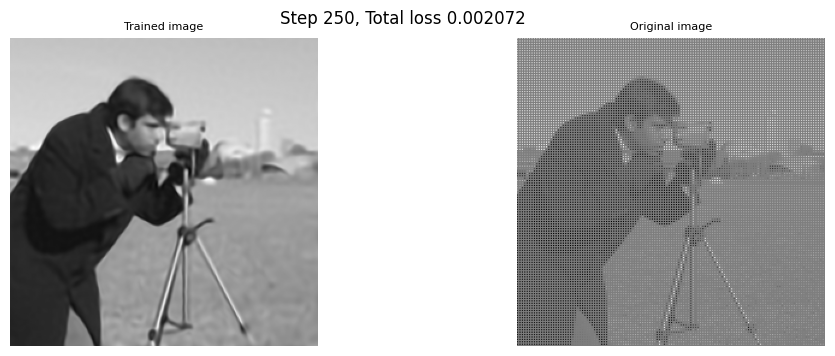

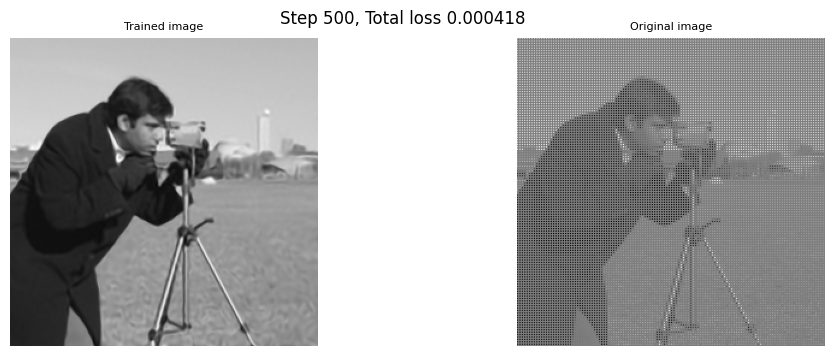

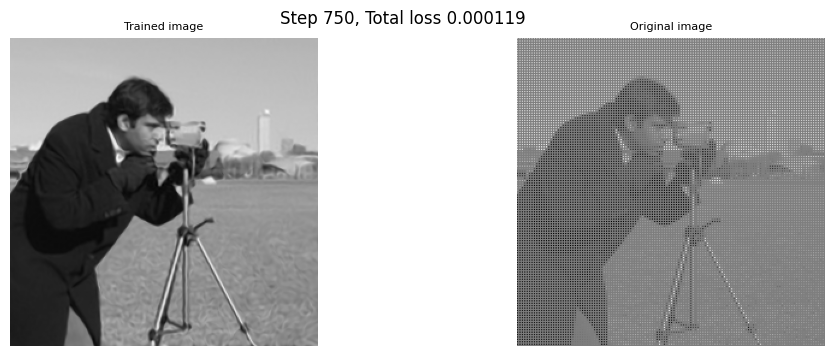

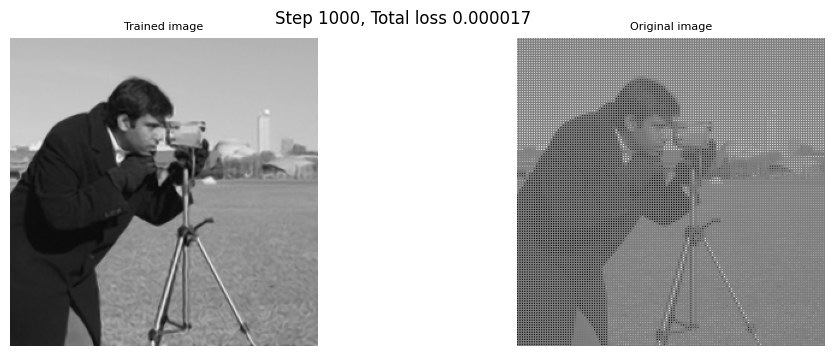

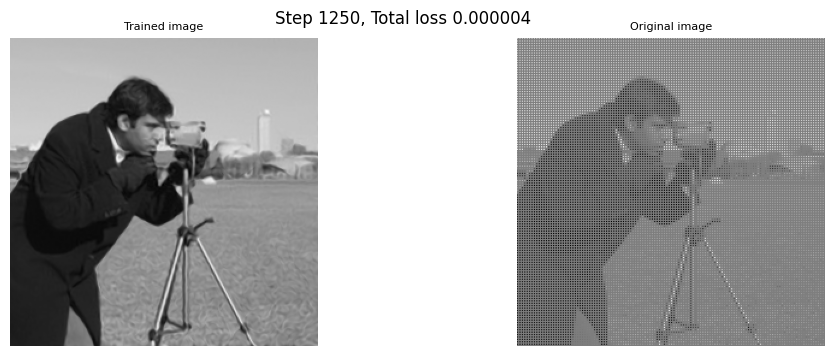

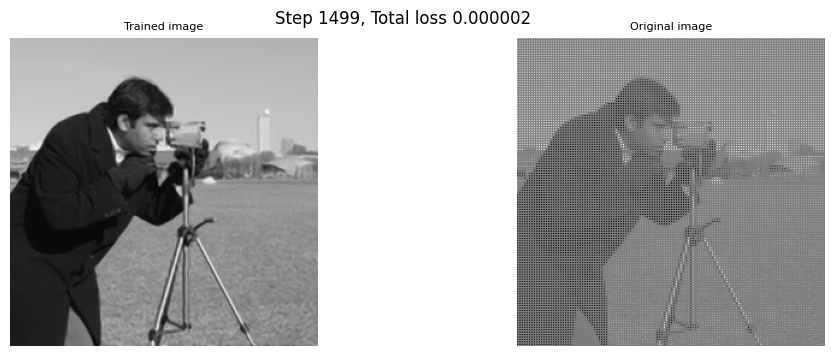

In [72]:
downscaled_cameraman = ImageFittingMasked(256, mask=upscale_mask)

upscale_loader = DataLoader(downscaled_cameraman, batch_size=1, pin_memory=True)

TOTAL_OPT_STEPS = 1500

upscaled_siren_img = train_img_masked(
    model=model_siren_img,
    optimizer=optim_siren_img,
    masked_loader=upscale_loader,
    device=DEVICE
)

Here we want to compare our strategy to basic option in upscaling - bicubic interpolation.

In [73]:
import torchvision.transforms.functional as TF

def bicubic_baseline(low_res_tensor: torch.Tensor, scale: int) -> torch.Tensor:
    formated_low_res_tensor = ((low_res_tensor + 1.0) / 2.0).clamp(0.0, 1.0)
    img = TF.to_pil_image(formated_low_res_tensor)
    H, W = img.size[1], img.size[0]
    new_size = (W * scale, H * scale)
    up_img = img.resize(new_size, resample=Image.BICUBIC)
    return TF.to_tensor(up_img) * 2.0 - 1.0

In [74]:
def compute_psnr(target: torch.Tensor,
                 prediction: torch.Tensor,
                 max_val: float = 1.0) -> float:
    if target.shape != prediction.shape:
        raise ValueError(f"Shape of tensors are unequal: {target.shape} vs {prediction.shape}")

    mse = torch.mean((target - prediction) ** 2).item()
    if mse == 0:
        return float('inf')

    psnr_value = 10 * torch.log10(torch.tensor(max_val**2 / mse)).item()
    return psnr_value

In [75]:
upscaled_siren_img_clamped = torch.clamp(upscaled_siren_img, -1.0, 1.0)
original_image = get_cameraman_tensor(256)[0]
bicubic_upscale = bicubic_baseline(original_image[0::2, 0::2], scale=2)[0]

psnr_siren = compute_psnr(original_image, upscaled_siren_img_clamped)
psnr_bicubic = compute_psnr(original_image, bicubic_upscale)

Our strategy is outperforming bicubic interpolation by far, and there are even [some papers about it](https://stanford.edu/class/ee367/Winter2021/projects/report_jiang.pdf).

In [76]:
print(f'Bicubic interpolation PSNR: {psnr_bicubic:.4f}')
print(f'SIREN interpolation PSNR: {psnr_siren:.4f}')

Bicubic interpolation PSNR: 22.0540
SIREN interpolation PSNR: 26.0222


In summary, SIREN’s sine-activated MLP—despite its minimal design—consistently outperforms standard baselines when fitting images, audio waveforms, and 3D geometry, and its flexibility even extends to creative tasks like super-resolution via grid masking. For clear intuition on why sinusoidal activations work, the original SIREN paper is a must-read: it’s concise, well explained, and packed with practical guidance.

---

**References**
* [SIREN](https://www.vincentsitzmann.com/siren/)
* [Paper](https://arxiv.org/abs/2006.09661)
* [Original colab notebook](https://colab.research.google.com/github/vsitzmann/siren/blob/master/explore_siren.ipynb)
* [SIREN github](https://github.com/vsitzmann/siren)